In [2]:
# ============================================================
# 04_Risk_Analysis.ipynb
# BTC/EUR Factor Strategy — Risk Analysis
# ============================================================
# This notebook provides a comprehensive risk assessment of
# the BTC/EUR factor strategy, motivated by the fat-tail
# return distribution identified in 01_EDA.ipynb.
#
# Contents:
#   1. Rolling risk metrics (Vol, VaR, CVaR, Drawdown)
#   2. Sharpe / Sortino / Beta analysis
#   3. Stress testing (6 scenarios)
#   4. Early warning dashboard (Risk Regime)
#
# Key finding from EDA:
#   BTC kurtosis = 9.39 (normal = 3)
#   → Standard risk models underestimate tail risk
#   → Hard stop loss + VIX filter added as protection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import os
from scipy import stats

plt.style.use("seaborn-v0_8-darkgrid")
os.makedirs("outputs", exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


In [3]:
# ── Cell 2: Fetch data and run backtest ──────────────────────

def fetch_btc_eur(start="2018-01-01"):
    df = yf.download("BTC-EUR", start=start, interval="1d",
                     auto_adjust=True, progress=False)
    df.columns    = df.columns.get_level_values(0)
    df.columns    = [c.lower() for c in df.columns]
    df.index.name = "date"
    df = df[["open","high","low","close","volume"]]
    df = df[df.index < pd.Timestamp.now().normalize()]
    return df

def fetch_macro(start="2018-01-01"):
    frames = []
    for ticker, name in [("^VIX","vix"),("^TNX","us10y"),
                         ("^IXIC","nasdaq"),("^GSPC","sp500")]:
        d = yf.download(ticker, start=start, interval="1d",
                        auto_adjust=True, progress=False)
        d.columns    = d.columns.get_level_values(0)
        d.index.name = "date"
        d = d[["Close"]].rename(columns={"Close": name})
        frames.append(d)
    macro = frames[0].join(frames[1:], how="outer")
    macro = macro[macro.index < pd.Timestamp.now().normalize()]
    return macro

def run_backtest(df, buy_threshold=0.3, sell_threshold=-0.3,
                 sl_mult=2.0, tp_mult=3.0, position_pct=0.3,
                 initial_capital=10000.0, hard_stop_pct=0.05,
                 vix_threshold=35.0):
    capital, position, entry_price = initial_capital, 0.0, 0.0
    stop_loss, take_profit, cooldown = 0.0, 0.0, 0
    trades, portfolio = [], []
    df_bt = df.dropna(subset=["signal_score","ATR","vix"]).copy()
    for i in range(len(df_bt)):
        row   = df_bt.iloc[i]
        price = row["close"]
        atr   = row["ATR"]
        score = row["signal_score"]
        vix   = row["vix"]
        date  = df_bt.index[i]
        total_value = capital + position * price
        if cooldown > 0:
            cooldown -= 1
        if position > 0:
            if price <= stop_loss:
                proceeds = position * price
                pnl      = proceeds - (position * entry_price)
                capital += proceeds
                trades.append({"date": date, "action": "STOP_LOSS",
                               "price": price, "pnl": pnl,
                               "pnl_pct": (price/entry_price-1)*100})
                position = 0.0
                cooldown = 2
            elif price >= take_profit:
                proceeds = position * price
                pnl      = proceeds - (position * entry_price)
                capital += proceeds
                trades.append({"date": date, "action": "TAKE_PROFIT",
                               "price": price, "pnl": pnl,
                               "pnl_pct": (price/entry_price-1)*100})
                position = 0.0
        if score > buy_threshold and position == 0 \
                and cooldown == 0 and vix < vix_threshold:
            invest      = min(total_value * position_pct, capital)
            position    = invest / price
            entry_price = price
            capital    -= invest
            stop_loss   = max(price - sl_mult*atr,
                              price*(1-hard_stop_pct))
            take_profit = price + tp_mult * atr
            trades.append({"date": date, "action": "BUY",
                           "price": price, "size": position,
                           "cost": invest, "sl": stop_loss,
                           "tp": take_profit, "score": score,
                           "vix": vix})
        elif score < sell_threshold and position > 0:
            proceeds = position * price
            pnl      = proceeds - (position * entry_price)
            capital += proceeds
            trades.append({"date": date, "action": "SELL",
                           "price": price, "pnl": pnl,
                           "pnl_pct": (price/entry_price-1)*100})
            position = 0.0
        if position > 0 and price > entry_price:
            new_sl = price - sl_mult * atr
            if new_sl > stop_loss:
                stop_loss = new_sl
        portfolio.append(capital + position * price)
    return pd.DataFrame(trades), portfolio

# ── Fetch ─────────────────────────────────────────────────────
print("Fetching data...")
btc   = fetch_btc_eur()
macro = fetch_macro()

df = btc.join(macro, how="left")
df[["vix","us10y","nasdaq","sp500"]] = \
    df[["vix","us10y","nasdaq","sp500"]].ffill()
df = df.dropna()

# ATR
tr = pd.concat([
    df["high"] - df["low"],
    abs(df["high"] - df["close"].shift(1)),
    abs(df["low"]  - df["close"].shift(1))
], axis=1).max(axis=1)
df["ATR"] = tr.rolling(14).mean()

# Factors + signal
df["f_rates"] = -df["us10y"].diff(5)
df["f_vix"]   =  df["vix"]
WEIGHTS = {"f_rates": 0.60, "f_vix": 0.40}
score   = pd.Series(0.0, index=df.index)
for factor, weight in WEIGHTS.items():
    mean   = df[factor].rolling(252, min_periods=60).mean()
    std    = df[factor].rolling(252, min_periods=60).std()
    z      = (df[factor] - mean) / (std + 1e-10)
    score += z.clip(-2, 2) * weight
df["signal_score"] = score
df = df.dropna()

# Backtest
two_years_ago    = pd.Timestamp.now().normalize() - pd.DateOffset(years=2)
df_bt            = df[df.index >= two_years_ago].copy()
trades_df, portfolio = run_backtest(df_bt, initial_capital=10000.0)
returns_strategy = pd.Series(
    portfolio, index=df_bt.index[:len(portfolio)]
).pct_change().dropna()

print(f"Data    : {len(df)} rows ({df.index[0].date()} → {df.index[-1].date()})")
print(f"Backtest: {len(df_bt)} rows ({df_bt.index[0].date()} → {df_bt.index[-1].date()})")
print(f"Trades  : {len(trades_df)}")

Fetching data...
Data    : 3025 rows (2018-03-07 → 2026-06-18)
Backtest: 729 rows (2024-06-19 → 2026-06-18)
Trades  : 94


In [4]:
# ── Cell 3: Risk metrics functions ───────────────────────────
# (copied from src/risk_metrics.py for standalone notebook use)

def rolling_volatility(returns, window=30):
    return returns.rolling(window).std() * np.sqrt(365) * 100

def var_historical(returns, confidence=0.95, window=252):
    return returns.rolling(window).quantile(1 - confidence)

def expected_shortfall(returns, confidence=0.95, window=252):
    return returns.rolling(window).apply(
        lambda x: x[x <= np.quantile(x, 1-confidence)].mean(),
        raw=True)

def rolling_drawdown(portfolio):
    peak = portfolio.cummax()
    return (portfolio - peak) / peak * 100

def max_drawdown(portfolio):
    return rolling_drawdown(portfolio).min()

def downside_deviation(returns, mar=0.0):
    downside = returns[returns < mar]
    return downside.std() * np.sqrt(365)

def sharpe_ratio(returns, risk_free=0.04):
    excess = returns - risk_free / 365
    return (excess.mean() / returns.std()) * np.sqrt(365) \
           if returns.std() > 0 else 0

def sortino_ratio(returns, risk_free=0.04, mar=0.0):
    excess = returns.mean() * 365 - risk_free
    dd     = downside_deviation(returns, mar)
    return excess / dd if dd > 0 else 0

def beta_aligned(s_ret, b_ret):
    aligned = pd.concat([s_ret, b_ret], axis=1).dropna()
    if len(aligned) < 10:
        return 0
    cov = np.cov(aligned.iloc[:,0], aligned.iloc[:,1])
    return cov[0,1] / cov[1,1] if cov[1,1] > 0 else 0

def stress_test(portfolio_values, position_pct=0.30):
    current_value  = portfolio_values[-1]
    position_value = current_value * position_pct
    scenarios = []
    for name, btc_shock, note in [
        ("BTC crash -20% (1 week)",         -0.20,
         "Hard stop limits loss to 5% of position"),
        ("Equity crash (Nasdaq -15%)",       -0.12,
         "VIX filter blocks new entries at VIX>35"),
        ("USD strengthening (EUR/USD -5%)",  -0.05,
         "BTC priced in USD, EUR weakening hurts"),
        ("Rate shock (+100bps US 10Y)",      -0.08,
         "us10y_5d factor triggers sell signal"),
        ("Volatility spike (VIX doubles)",   -0.10,
         "VIX filter prevents new entries"),
        ("Liquidity shock (volume -70%)",    -0.02,
         "No hard stop protection vs slippage"),
    ]:
        raw_loss    = position_value * btc_shock
        actual_loss = max(raw_loss, -position_value * 0.05) \
                      if "Liquidity" not in name else raw_loss
        scenarios.append({
            "scenario"          : name,
            "btc_impact"        : f"{btc_shock*100:.0f}%",
            "strategy_loss_eur" : round(actual_loss, 2),
            "strategy_loss_pct" : round(
                actual_loss / current_value * 100, 2),
            "portfolio_value"   : round(
                current_value + actual_loss, 2),
            "note"              : note
        })
    return pd.DataFrame(scenarios)

def compute_risk_regime(df, portfolio_values):
    risk    = pd.DataFrame(index=df.index)
    returns = df["close"].pct_change()
    risk["btc_vol_30d"] = \
        returns.rolling(30).std() * np.sqrt(365) * 100
    port_series      = pd.Series(
        portfolio_values, index=df.index[:len(portfolio_values)])
    risk["drawdown"] = rolling_drawdown(
        port_series).reindex(df.index)
    mom_5d  = df["close"].pct_change(5)
    mom_20d = df["close"].pct_change(20)
    risk["momentum_reversal"] = (
        (mom_5d < -0.03) & (mom_20d > 0.05)).astype(int)
    risk["mom_5d"]  = mom_5d * 100
    risk["mom_20d"] = mom_20d * 100
    vix_norm  = (df["vix"] - df["vix"].rolling(252).mean()) / \
                (df["vix"].rolling(252).std() + 1e-10)
    rate_norm = (df["us10y"].diff(5) -
                 df["us10y"].diff(5).rolling(252).mean()) / \
                (df["us10y"].diff(5).rolling(252).std() + 1e-10)
    macro_raw = (vix_norm * 0.5 + rate_norm * 0.5).clip(-3, 3)
    risk["macro_pressure"] = (
        (macro_raw - macro_raw.rolling(252).min()) /
        (macro_raw.rolling(252).max() -
         macro_raw.rolling(252).min() + 1e-10) * 100
    ).clip(0, 100)
    def classify(row):
        score = 0
        if row["btc_vol_30d"] > 80:      score += 2
        elif row["btc_vol_30d"] > 50:    score += 1
        if row["drawdown"] < -10:        score += 2
        elif row["drawdown"] < -5:       score += 1
        if row["macro_pressure"] > 70:   score += 2
        elif row["macro_pressure"] > 50: score += 1
        if row["momentum_reversal"]:     score += 1
        return "HIGH" if score >= 4 else \
               "MEDIUM" if score >= 2 else "LOW"
    risk["risk_regime"] = risk.apply(classify, axis=1)
    risk["vix"]         = df["vix"]
    risk["us10y"]       = df["us10y"]
    risk["close"]       = df["close"]
    return risk.dropna()

print("Risk functions loaded ✅")

Risk functions loaded ✅


In [5]:
# ── Cell 4: Compute risk metrics ─────────────────────────────

btc_returns = df_bt["close"].pct_change().dropna()

# Rolling metrics
vol_30d = rolling_volatility(btc_returns)
var_95  = var_historical(btc_returns, 0.95)
var_99  = var_historical(btc_returns, 0.99)
es_95   = expected_shortfall(btc_returns, 0.95)

# Summary metrics
port_series  = pd.Series(portfolio, index=df_bt.index[:len(portfolio)])
sharpe       = sharpe_ratio(returns_strategy)
sortino      = sortino_ratio(returns_strategy)
max_dd       = max_drawdown(port_series)
dd_dev       = downside_deviation(returns_strategy)

# Beta
nasdaq_ret   = df_bt["nasdaq"].pct_change().dropna()
sp500_ret    = df_bt["sp500"].pct_change().dropna()
btc_ret      = df_bt["close"].pct_change().dropna()
beta_nasdaq  = beta_aligned(returns_strategy, nasdaq_ret)
beta_sp500   = beta_aligned(returns_strategy, sp500_ret)
beta_btc     = beta_aligned(returns_strategy, btc_ret)

# Risk regime
risk_df      = compute_risk_regime(df_bt, portfolio)

print("── Risk Metrics ─────────────────────────────────────")
print(f"Sharpe Ratio          : {sharpe:.2f}")
print(f"Sortino Ratio         : {sortino:.2f}")
print(f"Max Drawdown          : {max_dd:.2f}%")
print(f"Downside Deviation    : {dd_dev*100:.2f}%")
print(f"BTC 30d Vol (latest)  : {vol_30d.iloc[-1]:.1f}%")
print(f"VaR  95% (daily)      : {var_95.iloc[-1]*100:.2f}%")
print(f"VaR  99% (daily)      : {var_99.iloc[-1]*100:.2f}%")
print(f"CVaR 95% (daily)      : {es_95.dropna().iloc[-1]*100:.2f}%")
print(f"Beta vs Nasdaq        : {beta_nasdaq:.3f}")
print(f"Beta vs S&P 500       : {beta_sp500:.3f}")
print(f"Beta vs BTC           : {beta_btc:.3f}")
print(f"Today's Risk Regime   : {risk_df['risk_regime'].iloc[-1]}")

── Risk Metrics ─────────────────────────────────────
Sharpe Ratio          : 0.37
Sortino Ratio         : 0.37
Max Drawdown          : -7.61%
Downside Deviation    : 9.77%
BTC 30d Vol (latest)  : 41.0%
VaR  95% (daily)      : -3.93%
VaR  99% (daily)      : -6.46%
CVaR 95% (daily)      : -5.87%
Beta vs Nasdaq        : 0.109
Beta vs S&P 500       : 0.140
Beta vs BTC           : 0.144
Today's Risk Regime   : LOW


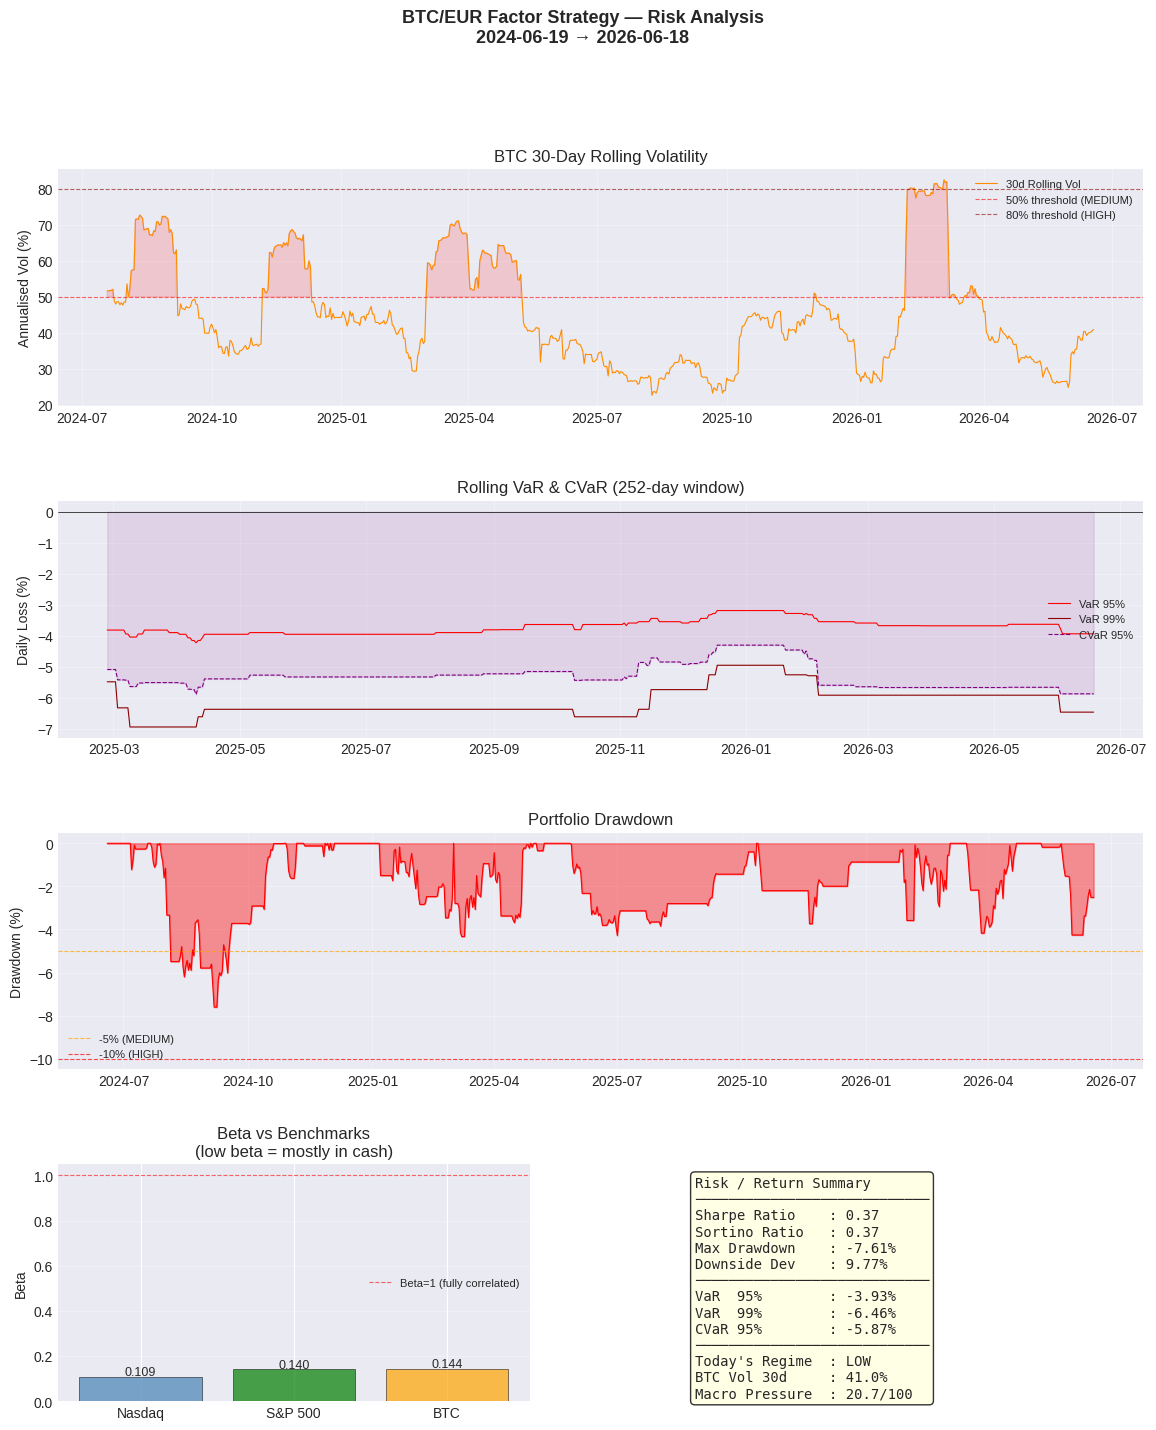

In [7]:
# ── Cell 5: Risk metrics visualisation ───────────────────────

# 对齐index
vol_30d_aligned = vol_30d.reindex(df_bt.index)
var_95_aligned  = var_95.reindex(df_bt.index)
var_99_aligned  = var_99.reindex(df_bt.index)
es_95_aligned   = es_95.reindex(df_bt.index)

fig = plt.figure(figsize=(14, 16))
fig.suptitle(
    f"BTC/EUR Factor Strategy — Risk Analysis\n"
    f"{df_bt.index[0].date()} → {df_bt.index[-1].date()}",
    fontsize=13, fontweight="bold"
)

gs = gridspec.GridSpec(4, 2, hspace=0.4, wspace=0.3)

# ── Rolling Volatility ────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(df_bt.index, vol_30d_aligned, color="darkorange", lw=0.8,
        label="30d Rolling Vol")
ax.axhline(50, color="red",     ls="--", lw=0.8,
           alpha=0.6, label="50% threshold (MEDIUM)")
ax.axhline(80, color="darkred", ls="--", lw=0.8,
           alpha=0.6, label="80% threshold (HIGH)")
ax.fill_between(df_bt.index, vol_30d_aligned, 50,
                where=vol_30d_aligned > 50,
                alpha=0.15, color="red")
ax.set_ylabel("Annualised Vol (%)")
ax.set_title("BTC 30-Day Rolling Volatility")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Rolling VaR ───────────────────────────────────────────────
ax = fig.add_subplot(gs[1, :])
ax.plot(df_bt.index, var_95_aligned * 100, color="red",
        lw=0.8, label="VaR 95%")
ax.plot(df_bt.index, var_99_aligned * 100, color="darkred",
        lw=0.8, label="VaR 99%")
ax.plot(df_bt.index, es_95_aligned  * 100, color="purple",
        lw=0.8, ls="--", label="CVaR 95%")
ax.fill_between(df_bt.index, es_95_aligned * 100, 0,
                alpha=0.1, color="purple")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Daily Loss (%)")
ax.set_title("Rolling VaR & CVaR (252-day window)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Drawdown ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, :])
dd_series = rolling_drawdown(port_series)
ax.fill_between(dd_series.index, dd_series.values, 0,
                alpha=0.4, color="red")
ax.plot(dd_series.index, dd_series.values,
        color="red", lw=0.8)
ax.axhline(-5,  color="orange", ls="--", lw=0.8,
           alpha=0.7, label="-5% (MEDIUM)")
ax.axhline(-10, color="red",    ls="--", lw=0.8,
           alpha=0.7, label="-10% (HIGH)")
ax.set_ylabel("Drawdown (%)")
ax.set_title("Portfolio Drawdown")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Beta comparison ───────────────────────────────────────────
ax = fig.add_subplot(gs[3, 0])
benchmarks = ["Nasdaq", "S&P 500", "BTC"]
betas      = [beta_nasdaq, beta_sp500, beta_btc]
colors_b   = ["steelblue", "green", "orange"]
bars = ax.bar(benchmarks, betas, color=colors_b,
              alpha=0.7, edgecolor="black", lw=0.5)
ax.axhline(1, color="red", ls="--", lw=0.8,
           alpha=0.6, label="Beta=1 (fully correlated)")
ax.axhline(0, color="black", lw=0.5)
for bar, val in zip(bars, betas):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Beta")
ax.set_title("Beta vs Benchmarks\n(low beta = mostly in cash)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# ── Risk/Return summary ───────────────────────────────────────
ax = fig.add_subplot(gs[3, 1])
ax.axis("off")
summary_text = (
    f"Risk / Return Summary\n"
    f"{'─'*28}\n"
    f"Sharpe Ratio    : {sharpe:.2f}\n"
    f"Sortino Ratio   : {sortino:.2f}\n"
    f"Max Drawdown    : {max_dd:.2f}%\n"
    f"Downside Dev    : {dd_dev*100:.2f}%\n"
    f"{'─'*28}\n"
    f"VaR  95%        : {var_95_aligned.iloc[-1]*100:.2f}%\n"
    f"VaR  99%        : {var_99_aligned.iloc[-1]*100:.2f}%\n"
    f"CVaR 95%        : {es_95_aligned.dropna().iloc[-1]*100:.2f}%\n"
    f"{'─'*28}\n"
    f"Today's Regime  : {risk_df['risk_regime'].iloc[-1]}\n"
    f"BTC Vol 30d     : {vol_30d_aligned.iloc[-1]:.1f}%\n"
    f"Macro Pressure  : {risk_df['macro_pressure'].iloc[-1]:.1f}/100"
)
ax.text(0.05, 0.95, summary_text,
        transform=ax.transAxes,
        fontsize=10, verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightyellow",
                  alpha=0.8))

plt.savefig("outputs/10_risk_metrics.png", dpi=150,
            bbox_inches="tight")
plt.show()

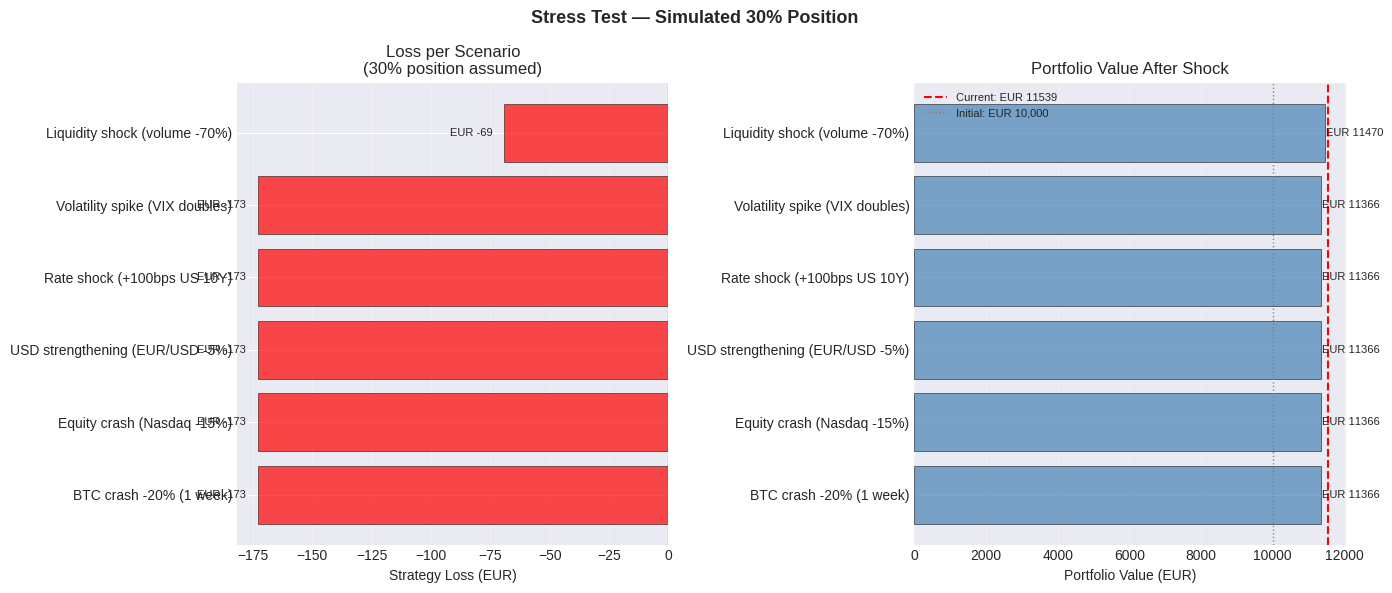


Stress Test Results:
                       scenario btc_impact  strategy_loss_eur  strategy_loss_pct                                    note
        BTC crash -20% (1 week)       -20%            -173.09               -1.5 Hard stop limits loss to 5% of position
     Equity crash (Nasdaq -15%)       -12%            -173.09               -1.5 VIX filter blocks new entries at VIX>35
USD strengthening (EUR/USD -5%)        -5%            -173.09               -1.5  BTC priced in USD, EUR weakening hurts
    Rate shock (+100bps US 10Y)        -8%            -173.09               -1.5    us10y_5d factor triggers sell signal
 Volatility spike (VIX doubles)       -10%            -173.09               -1.5         VIX filter prevents new entries
  Liquidity shock (volume -70%)        -2%             -69.24               -0.6     No hard stop protection vs slippage


In [8]:
# ── Cell 6: Stress test visualisation ────────────────────────

stress_df = stress_test(portfolio)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Stress Test — Simulated 30% Position",
             fontsize=13, fontweight="bold")

# ── Loss by scenario ──────────────────────────────────────────
ax = axes[0]
colors_s = ["red" if x < 0 else "green"
            for x in stress_df["strategy_loss_eur"]]
bars = ax.barh(stress_df["scenario"],
               stress_df["strategy_loss_eur"],
               color=colors_s, alpha=0.7,
               edgecolor="black", lw=0.5)
ax.axvline(0, color="black", lw=0.8)
for bar, val in zip(bars, stress_df["strategy_loss_eur"]):
    ax.text(val - 5 if val < 0 else val + 1,
            bar.get_y() + bar.get_height()/2,
            f"EUR {val:.0f}",
            va="center", ha="right" if val < 0 else "left",
            fontsize=8)
ax.set_xlabel("Strategy Loss (EUR)")
ax.set_title("Loss per Scenario\n(30% position assumed)")
ax.grid(True, alpha=0.3, axis="x")

# ── Portfolio value after shock ───────────────────────────────
ax = axes[1]
current = portfolio[-1]
ax.barh(stress_df["scenario"],
        stress_df["portfolio_value"],
        color="steelblue", alpha=0.7,
        edgecolor="black", lw=0.5)
ax.axvline(current, color="red", lw=1.5, ls="--",
           label=f"Current: EUR {current:.0f}")
ax.axvline(10000, color="gray", lw=1, ls=":",
           label="Initial: EUR 10,000")
for i, val in enumerate(stress_df["portfolio_value"]):
    ax.text(val + 10, i,
            f"EUR {val:.0f}",
            va="center", fontsize=8)
ax.set_xlabel("Portfolio Value (EUR)")
ax.set_title("Portfolio Value After Shock")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/11_stress_test.png", dpi=150,
            bbox_inches="tight")
plt.show()

# Print table
print("\nStress Test Results:")
print(stress_df[["scenario","btc_impact",
                 "strategy_loss_eur","strategy_loss_pct",
                 "note"]].to_string(index=False))

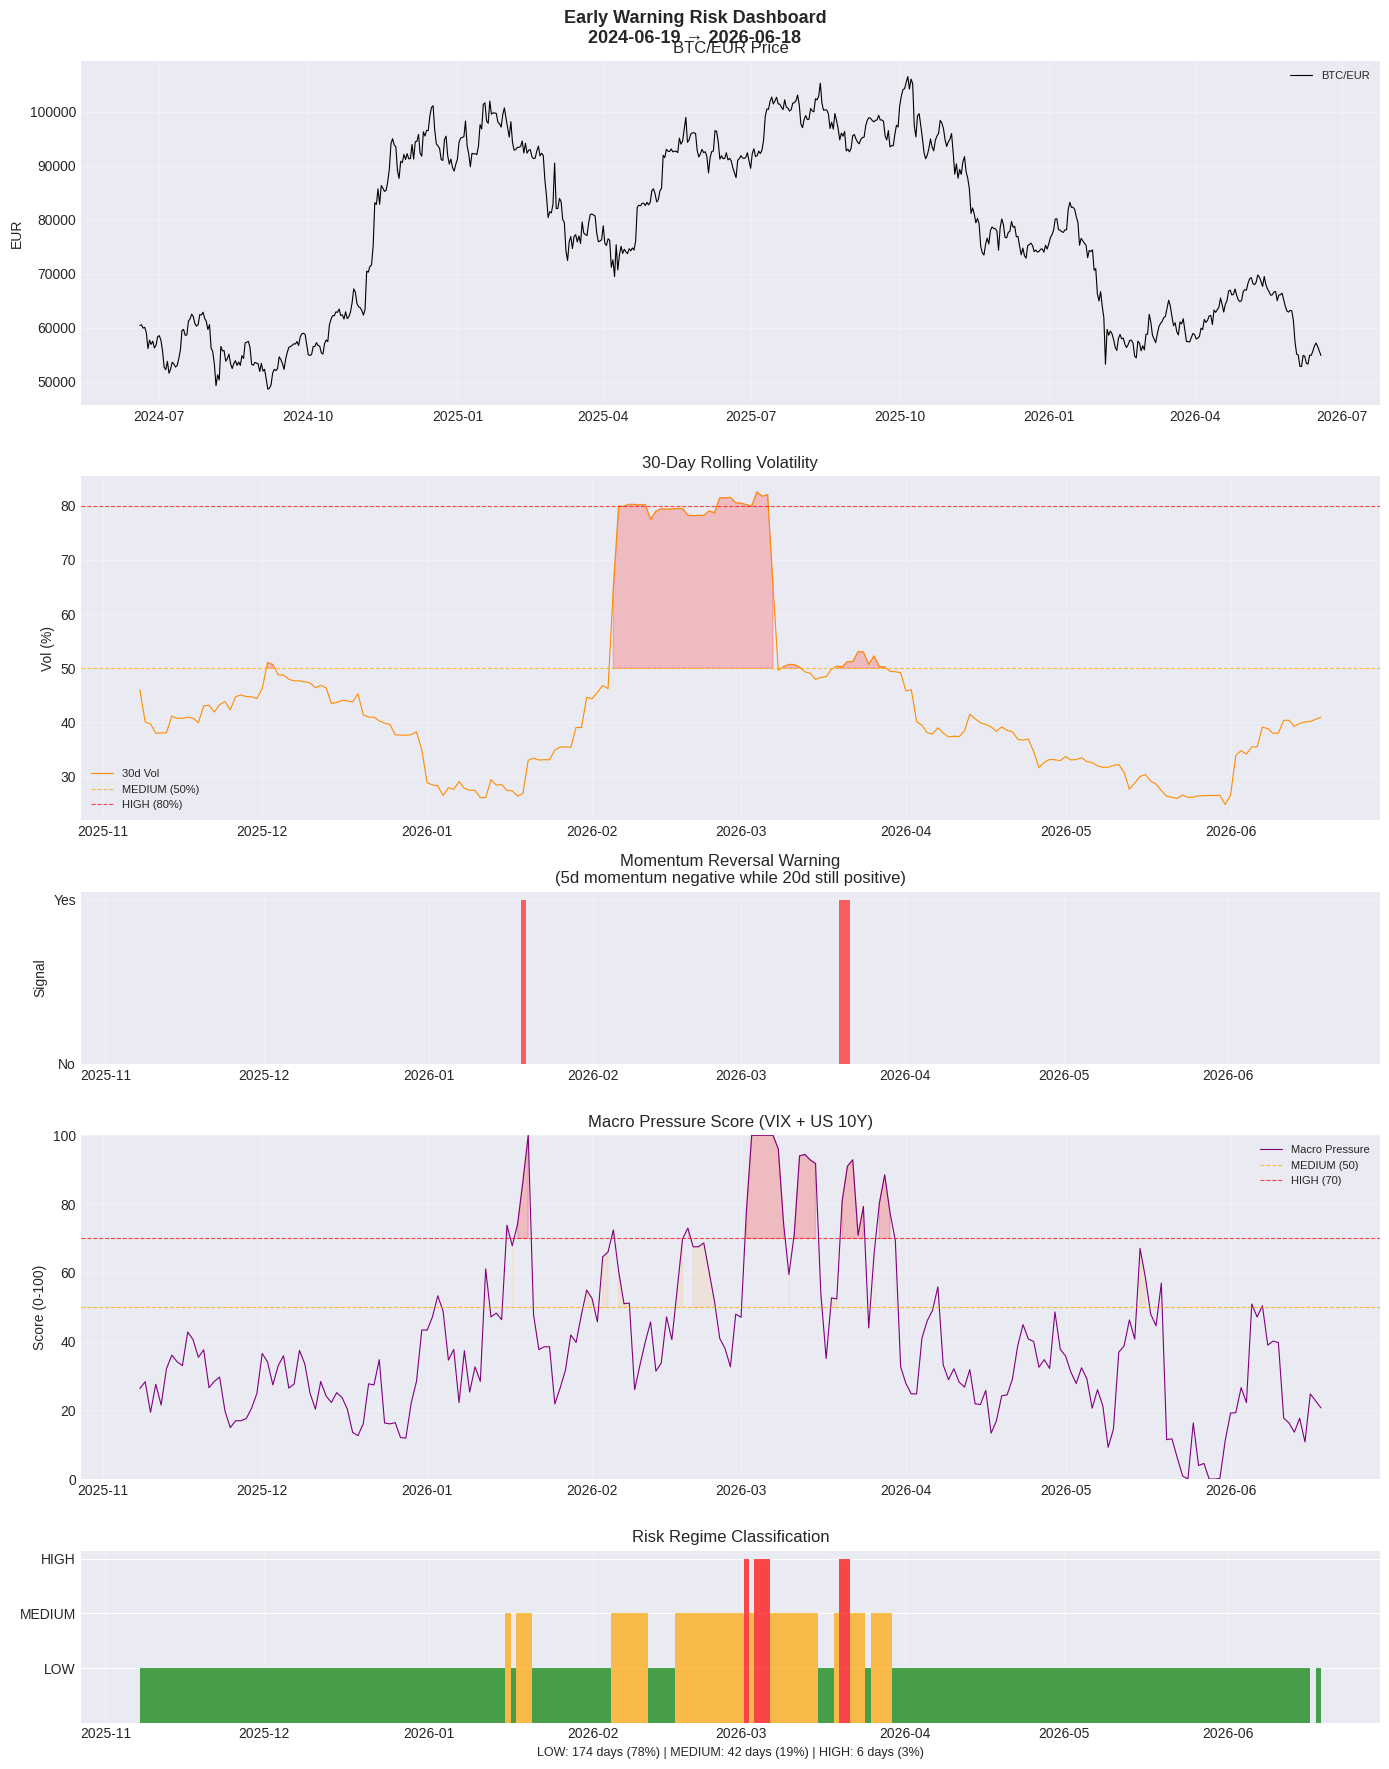

In [9]:
# ── Cell 7: Risk Dashboard ────────────────────────────────────

fig, axes = plt.subplots(5, 1, figsize=(14, 18),
                         gridspec_kw={"height_ratios": [2,2,1,2,1]})
fig.suptitle(
    f"Early Warning Risk Dashboard\n"
    f"{df_bt.index[0].date()} → {df_bt.index[-1].date()}",
    fontsize=13, fontweight="bold"
)

# ── BTC Price ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_bt.index, df_bt["close"],
        color="black", lw=0.8, label="BTC/EUR")
ax.set_ylabel("EUR")
ax.set_title("BTC/EUR Price")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Rolling Volatility ────────────────────────────────────────
ax = axes[1]
ax.plot(risk_df.index, risk_df["btc_vol_30d"],
        color="darkorange", lw=0.8, label="30d Vol")
ax.axhline(50, color="orange", ls="--", lw=0.8,
           alpha=0.7, label="MEDIUM (50%)")
ax.axhline(80, color="red",    ls="--", lw=0.8,
           alpha=0.7, label="HIGH (80%)")
ax.fill_between(risk_df.index, risk_df["btc_vol_30d"], 50,
                where=risk_df["btc_vol_30d"] > 50,
                alpha=0.2, color="red")
ax.set_ylabel("Vol (%)")
ax.set_title("30-Day Rolling Volatility")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Momentum Reversal Signal ──────────────────────────────────
ax = axes[2]
reversal_dates = risk_df[risk_df["momentum_reversal"] == 1].index
ax.bar(risk_df.index, risk_df["momentum_reversal"],
       color="red", alpha=0.6, width=1)
ax.set_ylabel("Signal")
ax.set_yticks([0, 1])
ax.set_yticklabels(["No", "Yes"])
ax.set_title("Momentum Reversal Warning\n"
             "(5d momentum negative while 20d still positive)")
ax.grid(True, alpha=0.3)

# ── Macro Pressure ────────────────────────────────────────────
ax = axes[3]
ax.plot(risk_df.index, risk_df["macro_pressure"],
        color="purple", lw=0.8, label="Macro Pressure")
ax.axhline(50, color="orange", ls="--", lw=0.8,
           alpha=0.7, label="MEDIUM (50)")
ax.axhline(70, color="red",    ls="--", lw=0.8,
           alpha=0.7, label="HIGH (70)")
ax.fill_between(risk_df.index, risk_df["macro_pressure"], 70,
                where=risk_df["macro_pressure"] > 70,
                alpha=0.2, color="red")
ax.fill_between(risk_df.index, risk_df["macro_pressure"], 50,
                where=(risk_df["macro_pressure"] > 50) &
                      (risk_df["macro_pressure"] <= 70),
                alpha=0.1, color="orange")
ax.set_ylabel("Score (0-100)")
ax.set_ylim(0, 100)
ax.set_title("Macro Pressure Score (VIX + US 10Y)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Risk Regime ───────────────────────────────────────────────
ax = axes[4]
regime_colors = {"LOW": "green", "MEDIUM": "orange", "HIGH": "red"}
regime_num    = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

for date, row in risk_df.iterrows():
    ax.bar(date, regime_num[row["risk_regime"]],
           color=regime_colors[row["risk_regime"]],
           alpha=0.7, width=1)

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(["LOW", "MEDIUM", "HIGH"])
ax.set_title("Risk Regime Classification")
ax.grid(True, alpha=0.3, axis="x")

# Regime distribution
regime_counts = risk_df["risk_regime"].value_counts()
total         = len(risk_df)
regime_text   = " | ".join([
    f"{r}: {regime_counts.get(r,0)} days "
    f"({regime_counts.get(r,0)/total*100:.0f}%)"
    for r in ["LOW","MEDIUM","HIGH"]
])
ax.set_xlabel(regime_text, fontsize=9)

plt.tight_layout()
plt.savefig("outputs/12_risk_dashboard.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [10]:
# ── Cell 8: Risk Summary ──────────────────────────────────────

today      = pd.Timestamp.now().normalize()
latest     = risk_df.iloc[-1]
regime     = latest["risk_regime"]
regime_emoji = {"LOW": "🟢", "MEDIUM": "🟡", "HIGH": "🔴"}

print("=" * 60)
print("  Risk Analysis Summary")
print("=" * 60)

print(f"""
ANALYSIS PERIOD
  {df_bt.index[0].date()} → {df_bt.index[-1].date()}
  ({len(df_bt)} trading days)

RETURN RISK METRICS
  Sharpe Ratio          : {sharpe:.2f}
  Sortino Ratio         : {sortino:.2f}
  Max Drawdown          : {max_dd:.2f}%
  Downside Deviation    : {dd_dev*100:.2f}%

TAIL RISK (252-day rolling window)
  VaR  95%              : {var_95_aligned.iloc[-1]*100:.2f}% daily
  VaR  99%              : {var_99_aligned.iloc[-1]*100:.2f}% daily
  CVaR 95%              : {es_95_aligned.dropna().iloc[-1]*100:.2f}% daily
  BTC 30d Vol           : {latest['btc_vol_30d']:.1f}% annualised

MARKET SENSITIVITY
  Beta vs Nasdaq        : {beta_nasdaq:.3f}
  Beta vs S&P 500       : {beta_sp500:.3f}
  Beta vs BTC           : {beta_btc:.3f}
  → Strategy beta << 1 because position = 30% of portfolio
    and strategy is frequently in cash

STRESS TEST (30% position = EUR {portfolio[-1]*0.3:.0f})
  Worst case loss       : EUR {stress_df['strategy_loss_eur'].min():.0f}
                          ({stress_df['strategy_loss_pct'].min():.1f}% of portfolio)
  Best protection       : Hard stop loss (max 5% per position)
  Additional protection : VIX filter blocks entries when VIX > 35

RISK REGIME DISTRIBUTION ({df_bt.index[0].date()} → {df_bt.index[-1].date()})
  LOW    : {(risk_df['risk_regime']=='LOW').sum()} days ({(risk_df['risk_regime']=='LOW').mean()*100:.0f}%)
  MEDIUM : {(risk_df['risk_regime']=='MEDIUM').sum()} days ({(risk_df['risk_regime']=='MEDIUM').mean()*100:.0f}%)
  HIGH   : {(risk_df['risk_regime']=='HIGH').sum()} days ({(risk_df['risk_regime']=='HIGH').mean()*100:.0f}%)

TODAY'S RISK SNAPSHOT (as of {today.date()})
  Risk Regime           : {regime_emoji.get(regime, '')} {regime}
  BTC Vol 30d           : {latest['btc_vol_30d']:.1f}%
  Drawdown              : {latest['drawdown']:.2f}%
  Macro Pressure        : {latest['macro_pressure']:.1f}/100
  VIX                   : {latest['vix']:.1f}
  US 10Y Yield          : {latest['us10y']:.3f}%
  Momentum Reversal     : {'⚠️  YES' if latest['momentum_reversal'] else '✅ NO'}
""")

# Save risk dashboard CSV
risk_export = risk_df[[
    "close","btc_vol_30d","drawdown",
    "macro_pressure","risk_regime","vix","us10y"
]].copy()
risk_export.to_csv("outputs/risk_dashboard.csv")
print("Risk dashboard saved → outputs/risk_dashboard.csv")
print("=" * 60)


  Risk Analysis Summary

ANALYSIS PERIOD
  2024-06-19 → 2026-06-18
  (729 trading days)

RETURN RISK METRICS
  Sharpe Ratio          : 0.37
  Sortino Ratio         : 0.37
  Max Drawdown          : -7.61%
  Downside Deviation    : 9.77%

TAIL RISK (252-day rolling window)
  VaR  95%              : -3.93% daily
  VaR  99%              : -6.46% daily
  CVaR 95%              : -5.87% daily
  BTC 30d Vol           : 41.0% annualised

MARKET SENSITIVITY
  Beta vs Nasdaq        : 0.109
  Beta vs S&P 500       : 0.140
  Beta vs BTC           : 0.144
  → Strategy beta << 1 because position = 30% of portfolio
    and strategy is frequently in cash

STRESS TEST (30% position = EUR 3462)
  Worst case loss       : EUR -173
                          (-1.5% of portfolio)
  Best protection       : Hard stop loss (max 5% per position)
  Additional protection : VIX filter blocks entries when VIX > 35

RISK REGIME DISTRIBUTION (2024-06-19 → 2026-06-18)
  LOW    : 174 days (78%)
  MEDIUM : 42 days (19%)
 